In [1]:
import os
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np

In [2]:
skel_dir = 'Y:/data/Eyewire2/morphologies-ew2/swc-final/2007c8b3d5870b8742b720823ceab1a0/9e713c5362f2535135fe15417bfec1fa'
swc_files = [f for f in os.listdir(skel_dir) if f.endswith('.npz')]
print(len(swc_files))

1631


In [15]:
from eyewire2_functional_analysis import data_loader

data_folder = "../../data/preprocessed-data"
nuc_col_master = "Updated Nuc ID\n(Oct 27)\nIF YOU UPDATE THIS COLUMN, ALSO UPDATE Final NucID!"
seg_col_master = "Updated Seg ID\n(Oct 27)\nIF YOU UPDATE THIS COLUMN, ALSO UPDATE Final SegID!"

df_merged = data_loader.load_df_rois_morph(
    morph_folder="../../data/morphological-data",
    data_folder="../../data/preprocessed-data",
    nuc_col_master=nuc_col_master,
    seg_col_master=seg_col_master,
)

In [16]:
from eyewire2_functional_analysis import plot

from eyewire2_functional_analysis.style import set_rc_params

set_rc_params(notebook_dpi=None)

In [29]:
def plot_cells(df):
    assert df.shape[0] > 0, "No data to plot"
    df = add_skels(df)

    fig, axs = plt.subplots(len(df), 6, figsize=(7, len(df) * 0.9), width_ratios=(0.8, 0.8, 0.5, 1.6, 1.6, 0.6))

    for i, ax_to_replace in enumerate(axs[:, -1]):
        ax_to_replace.remove()
        polar_ax = fig.add_subplot(ax_to_replace.get_subplotspec(), polar=True)
        axs[i, -1] = polar_ax


    for i, (seg_id, row) in enumerate(df.iterrows()):
        ax = axs[i, 2]
        pass
        #plot.plot_ipl_profile(ax=ax, row=row)

        ax = axs[i, 1]
        skel_rot = rotate_skel(row['skel'], rotation_deg=150)

        xmax, ymax, zmax = np.max(skel_rot.nodes[skel_rot.ntype == 3], axis=0)
        xmin, ymin, zmin = np.min(skel_rot.nodes[skel_rot.ntype == 3], axis=0)

        xlim = (xmin - 25, xmax + 25)
        ylim = (ymin - 25, ymax + 25)

        sk.plot.projection(skel_rot,
                           ax=ax, xlim=ylim, ylim=xlim, plane='yx', draw_cylinders=False)
        plot.plot_scale_bar(ax=ax, x0=np.mean(ylim), y0=xlim[0], size=100, text=True, unit='µm', tdist=4, fontsize=12)
        #sx, sy, sz = plot.plot_morph(ax=ax, row=row, rad=rad)
        ax.set_rasterized(True)

        # ax = axs[i, 0]
        # rad = 180
        # ax.set_xlim(sx - rad, sx + rad)
        # ax.set_ylim(sy + rad, sy - rad)
        # plot.plot_scale_bar(ax=ax, x0=sx, y0=sy, size=100, text=True, unit='µm', tdist=-0.1 * rad, fontsize=12)

        ax = axs[i, 3]
        plot.plot_chirp(ax=ax, row=row)
        if i == (df.shape[0] - 1):
            plot.plot_scale_bar(ax=ax, x0=1, y0=-0.4, size=2, text=True, tdist=0.1, unit='s')
        ax.set_ylim(-0.5, +1.1)

        ax = axs[i, 4]
        plot.plot_bar(ax=ax, row=row, annotate_dirs=False, annotate_symbols=i == 0)
        if i == (df.shape[0] - 1):
            plot.plot_scale_bar(ax=ax, x0=1, y0=-0.4, size=2, text=True, tdist=0.1, unit='s')
        ax.set_ylim(-0.5, +1.1)

        ax = axs[i, 5]
        plot.plot_bar_dir(ax=ax, row=row)

    for ax in axs[:, :-1].flat:
        ax.set(xlabel=None, ylabel=None, xticks=[], yticks=[])
        ax.axis('off')
        ax.set_facecolor((1, 1, 1, 0))

    plt.tight_layout(h_pad=0.4, w_pad=0)
    return fig, axs

In [30]:
from eyewire2_functional_analysis.skeleton import rotate_skel
import skeliner as sk


def add_skels(df):
    df = df.copy()
    df['swc_path'] = df[seg_col_master].apply(lambda x: os.path.join(skel_dir, f"{x}.npz"))
    df['swc_exists'] = df['swc_path'].apply(lambda x: os.path.isfile(x))
    if np.any(~df['swc_exists']):
        print('SWC not found:', df[~df['swc_exists']][seg_col_master].values)
    df = df[df['swc_exists']]
    df['skel'] = df['swc_path'].apply(lambda x: sk.io.load_npz(x))
    return df

SWC not found: ['720575940563641563']


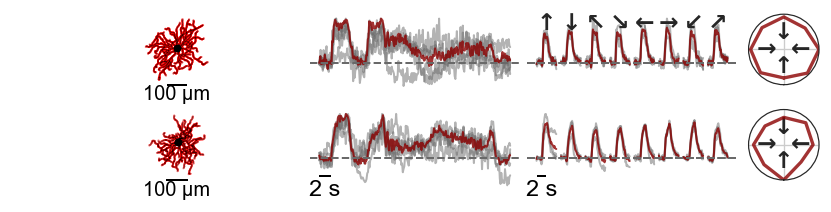

In [31]:
# https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5112165299126272

son_alpha_nuc_ids = [
    720575940557717614, 720575940562274734, 720575940562660177,
    #720575940562905653,
]

df_type = deepcopy(df_merged[
    (df_merged[nuc_col_master].astype(int).isin(son_alpha_nuc_ids))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
])

fig, axs = plot_cells(df_type.iloc[[0, 1, 2]])
plt.savefig('./figures/examples_son_alphas.svg', transparent=True, dpi=600)
plt.show()

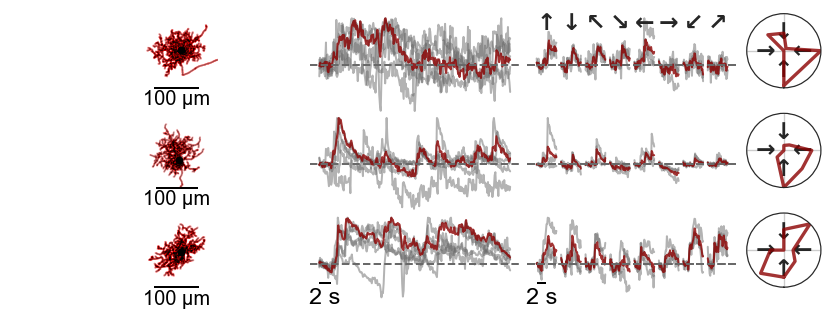

In [32]:
# https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5838312064417792

uhd_list = [
    720575940554823070, 720575940555457712, 720575940558194576
]

df_type = df_merged[
    (df_merged[nuc_col_master].astype(int).isin(uhd_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
]

fig, axs = plot_cells(df_type)
plt.savefig('./figures/examples_uhd.svg', transparent=True, dpi=600)
plt.show()

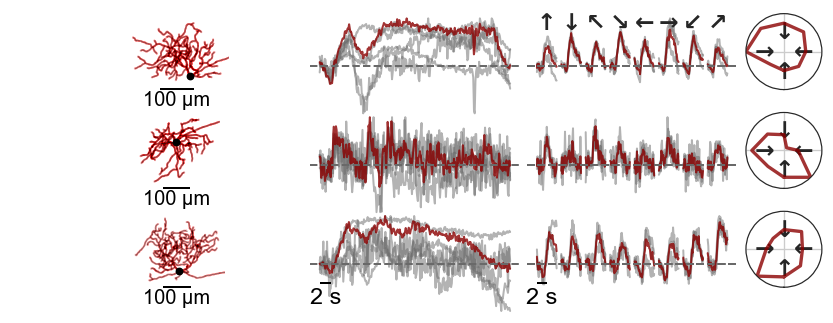

In [33]:
# https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/5838312064417792

ds_seg_list = [
    720575940547915976, 720575940550011222, 720575940550605504, 720575940554848042, 720575940555722562, 720575940559131851, 720575940567685999, 720575940570207675, 720575940579841113
]

df_type = df_merged[
    (df_merged[seg_col_master].astype(int).isin(ds_seg_list))
    & ((df_merged.chirp_qidx > 0.45) | (df_merged.bar_qidx > 0.6))
    & (df_merged["Status"] == 'Complete')
]

fig, axs = plot_cells(df_type.iloc[[0, 1, 2]])
plt.savefig('./figures/examples_ds.svg', transparent=True, dpi=600)
plt.show()